# COT Metrics Exploration

This notebook provides an interactive environment to visualize and understand the **Coverage, Overlap, Trespass, and Excess (COTe)** metrics for Document Layout Analysis.

We will visualize how different bounding box layouts affect each metric component.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import List, Dict, Any
import sys
import os

sys.path.append(os.path.abspath('.'))

from cot_score.metrics import coverage, overlap, trespass, excess, cote_score

## Visualization Helper Functions

Definition of `plot_scenario` to visualize bounding boxes and calculate metrics.

In [ ]:
def plot_scenario(gt_boxes, pred_boxes, title, img_width=100, img_height=100):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, img_width)
    ax.set_ylim(0, img_height)
    ax.set_aspect('equal')
    ax.invert_yaxis()

    for box in gt_boxes:
        rect = patches.Rectangle((box['x'], box['y']), box['width'], box['height'], linewidth=2, edgecolor='green', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(box['x'], box['y'] - 2, "GT", color='green', fontsize=10)

    for i, box in enumerate(pred_boxes):
        rect = patches.Rectangle((box['x'], box['y']), box['width'], box['height'], linewidth=2, edgecolor='red', facecolor='red', alpha=0.1, linestyle='-')
        border = patches.Rectangle((box['x'], box['y']), box['width'], box['height'], linewidth=2, edgecolor='red', facecolor='none', linestyle='-')
        ax.add_patch(rect)
        ax.add_patch(border)
        ax.text(box['x'], box['y'] + box['height'] + 5, f"P{i+1}", color='red', fontsize=10)

    # Normalized metrics
    c = coverage(pred_boxes, gt_boxes, img_width, img_height)
    o = overlap(pred_boxes, gt_boxes, img_width, img_height)
    t = trespass(pred_boxes, gt_boxes, img_width, img_height)
    e = excess(pred_boxes, gt_boxes, img_width, img_height)
    cot, _, _, _, _ = cote_score(pred_boxes, gt_boxes, img_width, img_height)

    # Raw metrics
    c_raw = coverage(pred_boxes, gt_boxes, img_width, img_height, return_raw=True)
    o_raw = overlap(pred_boxes, gt_boxes, img_width, img_height, return_raw=True)
    t_raw = trespass(pred_boxes, gt_boxes, img_width, img_height, return_raw=True)
    e_raw = excess(pred_boxes, gt_boxes, img_width, img_height, return_raw=True)

    metrics_text = (
        f"NORMALIZED METRICS:\n"
        f"Coverage: {c:.3f}\n"
        f"Overlap:  {o:.3f}\n"
        f"Trespass: {t:.3f}\n"
        f"Excess:   {e:.3f}\n"
        f"----------------\n"
        f"COT Score: {cot:.3f}\n\n"
        f"RAW METRICS:\n"
        f"Coverage: {c_raw[0]:.1f} / {c_raw[1]:.1f}\n"
        f"Overlap:  {o_raw[0]:.3f} / {o_raw[1]:.1f}\n"
        f"Trespass: {t_raw[0]:.3f} / {t_raw[1]:.3f}\n"
        f"Excess:   {e_raw[0]:.1f} / {e_raw[1]:.1f}"
    )

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(1.02, 1.0, metrics_text, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props, fontfamily='monospace')

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## Scenario 1: High Coverage (Ideal)
A single prediction perfectly covers a single ground truth. Ideal state.

TypeError: unsupported format string passed to tuple.__format__

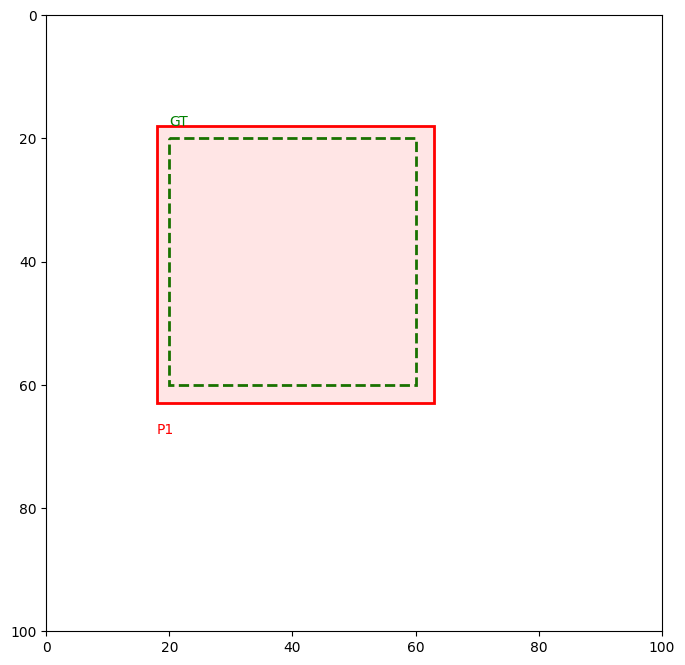

In [6]:
gt1 = [{'x': 20, 'y': 20, 'width': 40, 'height': 40}]
pred1 = [{'x': 18, 'y': 18, 'width': 45, 'height': 45}]
plot_scenario(gt1, pred1, "Scenario 1: High Coverage")

## Scenario 2: Partial Coverage
Prediction only covers half the ground truth.

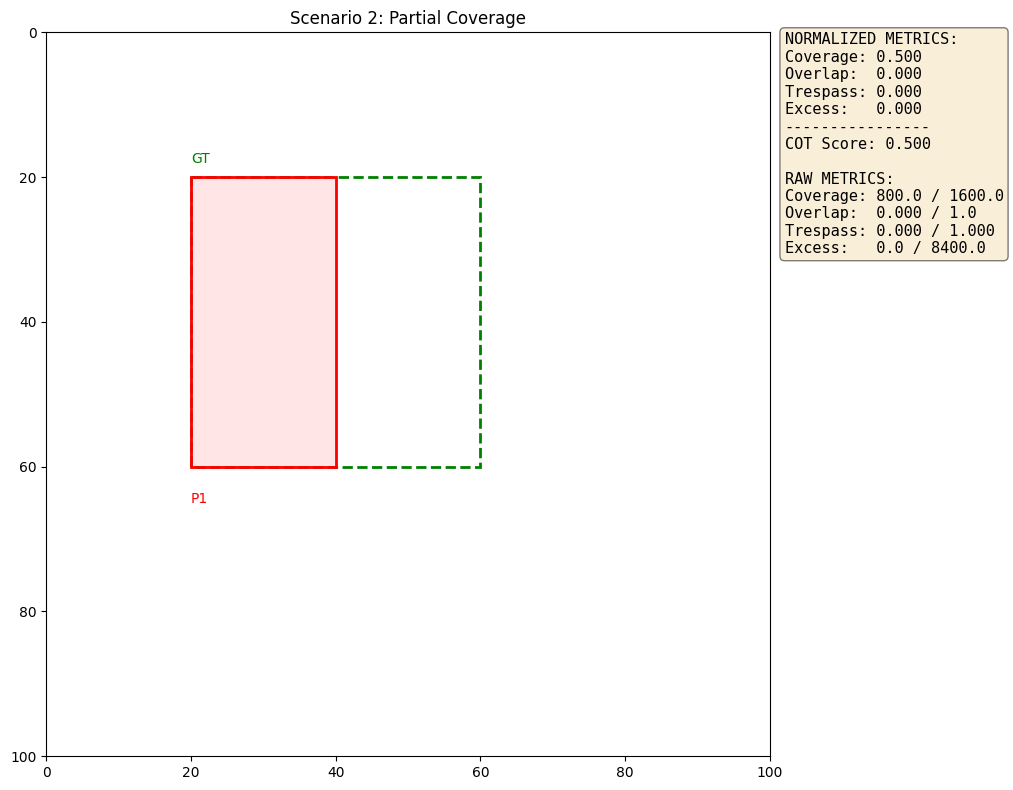

In [15]:
gt2 = [{'x': 20, 'y': 20, 'width': 40, 'height': 40}]
pred2 = [{'x': 20, 'y': 20, 'width': 20, 'height': 40}]
plot_scenario(gt2, pred2, "Scenario 2: Partial Coverage")

## Scenario 3: High Overlap
Two predictions cover the same area. Overlap penalizes redundancy.

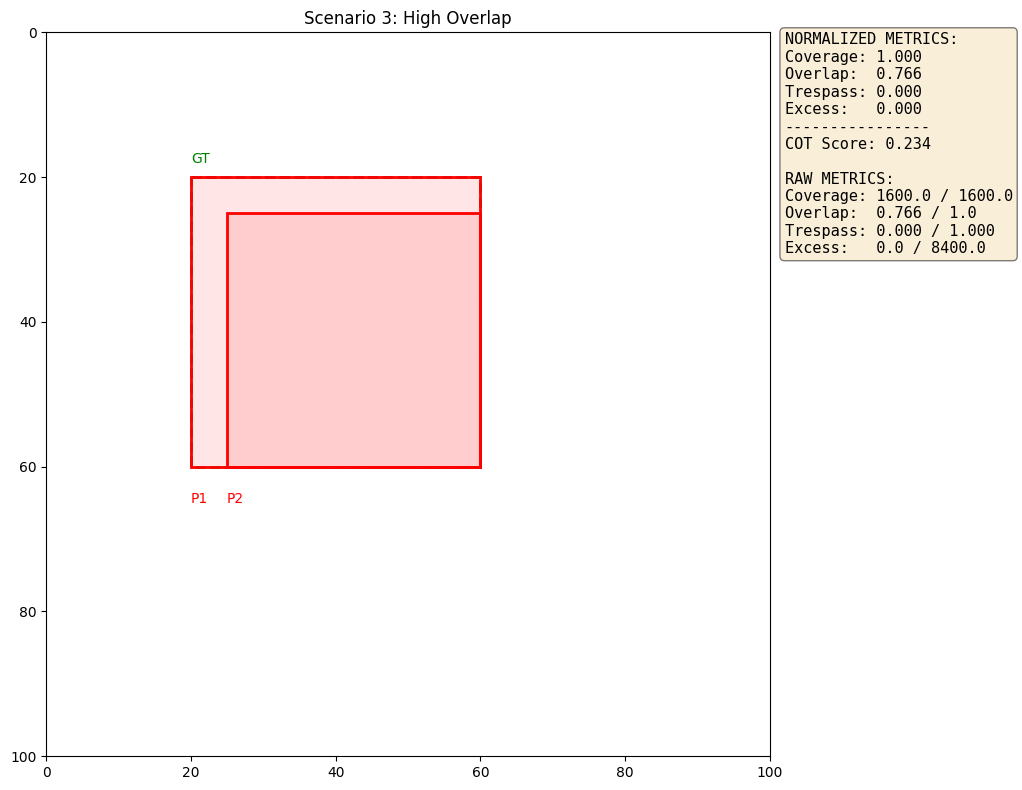

In [16]:
gt3 = [{'x': 20, 'y': 20, 'width': 40, 'height': 40}]
pred3 = [
    {'x': 20, 'y': 20, 'width': 40, 'height': 40},
    {'x': 25, 'y': 25, 'width': 35, 'height': 35}
]
plot_scenario(gt3, pred3, "Scenario 3: High Overlap")

## Scenario 4: High Trespass
A single prediction is assigned to one Ground Truth but trespasses significantly onto another. This is a merge error.

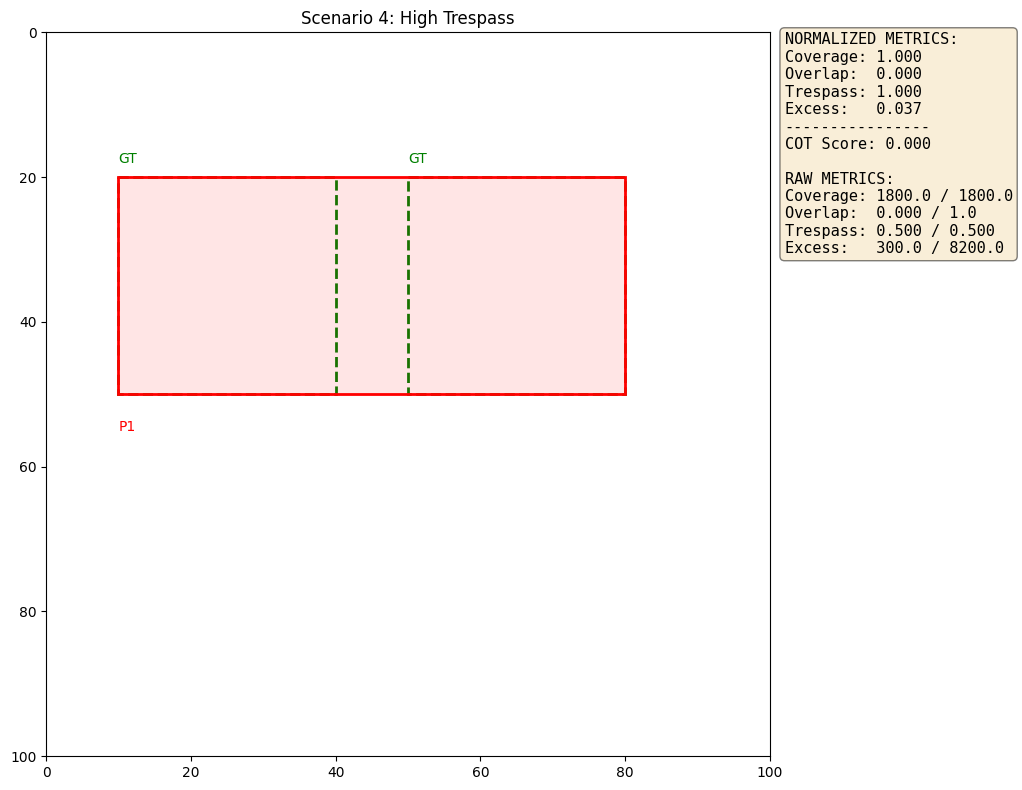

In [17]:
gt4 = [
    {'x': 10, 'y': 20, 'width': 30, 'height': 30},
    {'x': 50, 'y': 20, 'width': 30, 'height': 30}
]
pred4 = [{'x': 10, 'y': 20, 'width': 70, 'height': 30}]
plot_scenario(gt4, pred4, "Scenario 4: High Trespass")

## Scenario 6: Mixed COT
Demonstrates interaction of metrics. Overlap in background (gap between GTs) is IGNORED by overlap metric.

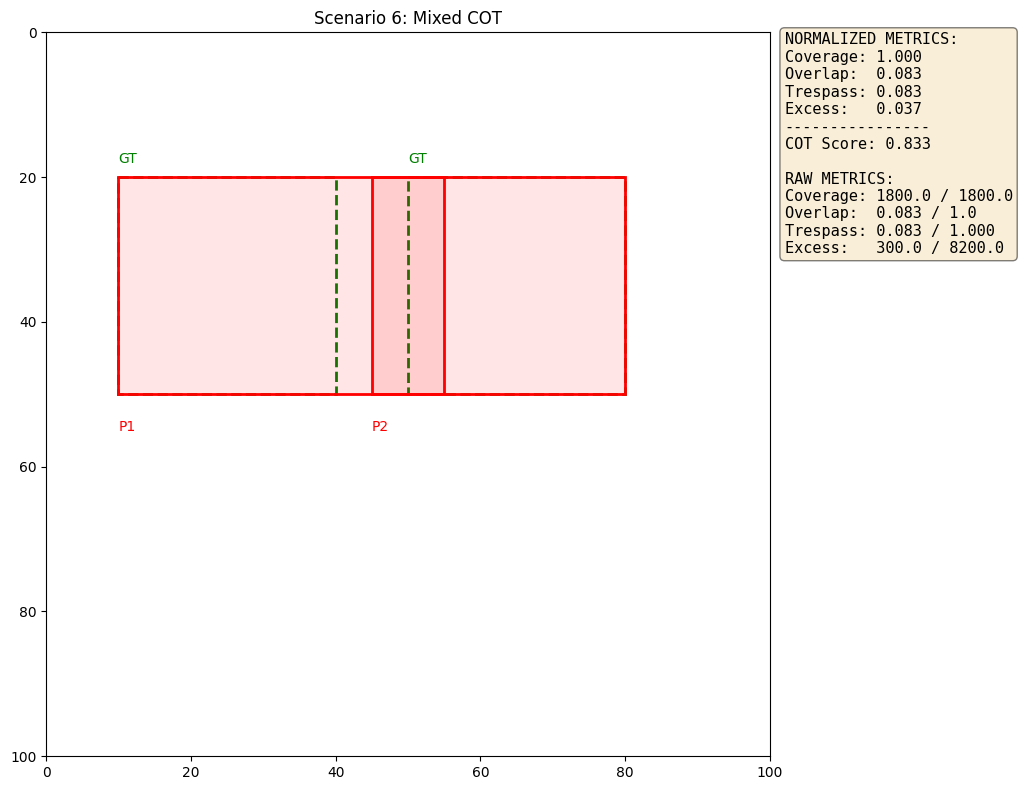

In [18]:
gt6 = [
    {'x': 10, 'y': 20, 'width': 30, 'height': 30},
    {'x': 50, 'y': 20, 'width': 30, 'height': 30}
]
pred6 = [
    {'x': 10, 'y': 20, 'width': 45, 'height': 30},
    {'x': 45, 'y': 20, 'width': 35, 'height': 30}
]
plot_scenario(gt6, pred6, "Scenario 6: Mixed COT")

## Scenario 7: Background Overlap
Predictions overlap entirely in white space. Overlap metric is 0.0 because overlap must be within a GT region.

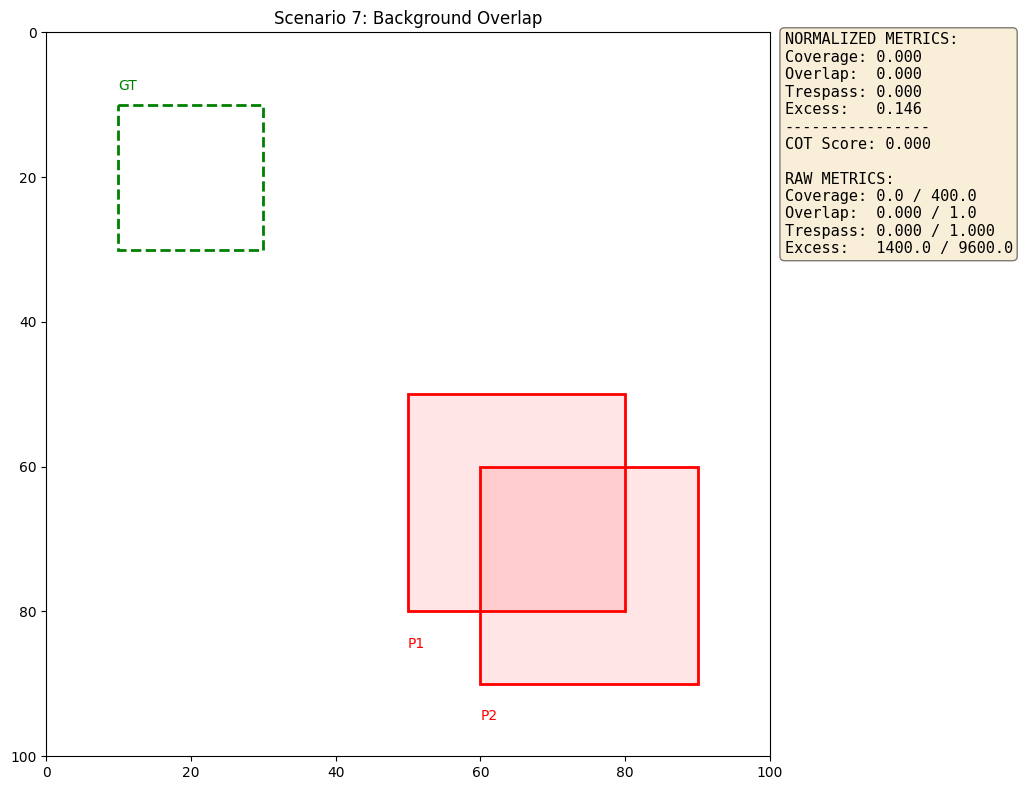

In [19]:
gt7 = [{'x': 10, 'y': 10, 'width': 20, 'height': 20}]
pred7 = [
    {'x': 50, 'y': 50, 'width': 30, 'height': 30},
    {'x': 60, 'y': 60, 'width': 30, 'height': 30}
]
plot_scenario(gt7, pred7, "Scenario 7: Background Overlap")